In [3]:
#A
import numpy as np

np.random.seed(42)

# Generate m0, m1, ..., m9
means_pos=np.random.multivariate_normal(mean=[1,0],cov=[[1,0],[0,1]],size=10)          #Geometric Meaning- The centers are scattered around (1,0) in a circular cloud. Because equal variance in both directions.

# Generate m'0, m'1, ..., m'9
means_neg=np.random.multivariate_normal(mean=[0,1],cov=[[1,0],[0,1]],size=10)          #Class +1 tends near (1,0) & Class −1 tends near (0,1)

#B&C

xpos=[]
xneg=[]

for i in range(10):
    pts=np.random.multivariate_normal(mean=means_pos[i],cov=[[0.1,0],[0,0.1]],size=10)
    xpos.append(pts)

for j in range(10):
    pts=np.random.multivariate_normal(mean=means_neg[j],cov=[[0.1,0],[0,0.1]],size=10)
    xneg.append(pts)

xpos=np.vstack(xpos)
xneg=np.vstack(xneg)

x = np.vstack((xpos, xneg))
y = np.array([1]*100 + [-1]*100)



#-----Gini function------#

def Gini(y):
    if len(y)==0:
        return 0
    p=np.mean(y==1)
    G=1-(p**2+(1-p)**2)
    return G

#----find best split-------#

def best_split(x,y):                     ##
    
    n,d=x.shape
    
    best_feature, best_thresh=None,None
    best_gini=float('inf')
    
    for j in range(d):
        thresholds=np.unique(x[:,j])

        for t in thresholds:
            left=y[x[:,j]<=t]
            right=y[x[:,j]>t]

            g_split=(len(left)*Gini(left)+len(right)*Gini(right))/n              # take n not 200

            if g_split<best_gini:
                best_gini=g_split
                best_feature=j
                best_thresh=t
                
    return best_feature, best_thresh


#------Build Tree Recursively----------#

def build_tree(x,y,depth=0,max_depth=2):
    if depth==max_depth or len(set(y))==1:
        return{"label":np.sign(np.sum(y))}

    j,t=best_split(x,y)

    left_idx=x[:,j]<=t
    right_idx=x[:,j]>t

    return {"feature":j,
            "threshold":t,
            "left":build_tree(x[left_idx],y[left_idx],depth+1,max_depth),
            "right":build_tree(x[right_idx],y[right_idx],depth+1,max_depth)}

#------ train tree ------#

tree=build_tree(x,y,max_depth=2)
print(tree)
            

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=["x1","x2"], class_names=["-1","1"])
plt.show()
    
        

{'feature': 0, 'threshold': np.float64(0.5837419845508584), 'left': {'feature': 1, 'threshold': np.float64(0.6923231199282124), 'left': {'label': np.int64(-1)}, 'right': {'label': np.int64(-1)}}, 'right': {'feature': 1, 'threshold': np.float64(0.1702301550273312), 'left': {'label': np.int64(1)}, 'right': {'label': np.int64(1)}}}


NameError: name 'clf' is not defined

<Figure size 1200x800 with 0 Axes>


Sklearn Tree:
Features: [ 0  1  1 -2 -2  0 -2 -2  1  0 -2 -2  1 -2 -2]
Thresholds: [ 0.59103185  0.70590705 -1.32958335 -2.         -2.          0.05360054
 -2.         -2.          0.1704092   0.70050782 -2.         -2.
  1.12273699 -2.         -2.        ]


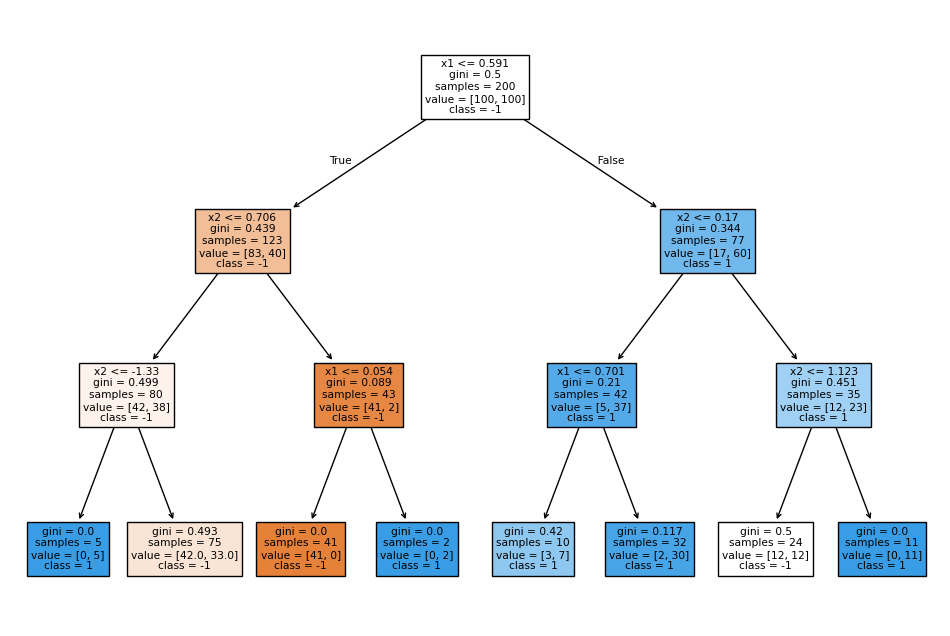

In [4]:
#B
import numpy as np

np.random.seed(42)

# Generate m0, m1, ..., m9
means_pos=np.random.multivariate_normal(mean=[1,0],cov=[[1,0],[0,1]],size=10)          #Geometric Meaning- The centers are scattered around (1,0) in a circular cloud. Because equal variance in both directions.

# Generate m'0, m'1, ..., m'9
means_neg=np.random.multivariate_normal(mean=[0,1],cov=[[1,0],[0,1]],size=10)          #Class +1 tends near (1,0) & Class −1 tends near (0,1)

#B&C

xpos=[]
xneg=[]

for i in range(10):
    pts=np.random.multivariate_normal(mean=means_pos[i],cov=[[0.1,0],[0,0.1]],size=10)
    xpos.append(pts)

for j in range(10):
    pts=np.random.multivariate_normal(mean=means_neg[j],cov=[[0.1,0],[0,0.1]],size=10)
    xneg.append(pts)

xpos=np.vstack(xpos)
xneg=np.vstack(xneg)

x = np.vstack((xpos, xneg))
y = np.array([1]*100 + [-1]*100)



#-----Gini function------#

def Gini(y):
    if len(y)==0:
        return 0
    p=np.mean(y==1)
    G=1-(p**2+(1-p)**2)
    return G

#----find best split-------#

def best_split(x,y):                     ##
    
    n,d=x.shape
    
    best_feature, best_thresh=None,None
    best_gini=float('inf')
    
    for j in range(d):
        thresholds=np.unique(x[:,j])

        for t in thresholds:
            left=y[x[:,j]<=t]
            right=y[x[:,j]>t]

            g_split=(len(left)*Gini(left)+len(right)*Gini(right))/n              # take n not 200

            if g_split<best_gini:
                best_gini=g_split
                best_feature=j
                best_thresh=t
                
    return best_feature, best_thresh


#------Build Tree Recursively----------#

def build_tree(x,y,depth=0,max_depth=3):
    if len(y)<=10 or len(set(y))==1:
        return{"label":np.sign(np.sum(y))}

    j,t=best_split(x,y)

    left_idx=x[:,j]<=t
    right_idx=x[:,j]>t

    return {"feature":j,
            "threshold":t,
            "left":build_tree(x[left_idx],y[left_idx],depth+1,max_depth),
            "right":build_tree(x[right_idx],y[right_idx],depth+1,max_depth)}

#------ train tree ------#

tree=build_tree(x,y,max_depth=2)
tree
            

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=11,   # split only if >10 points
    random_state=42
)

clf.fit(x, y)

print("\nSklearn Tree:")
print("Features:", clf.tree_.feature)
print("Thresholds:", clf.tree_.threshold)
    

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=["x1","x2"], class_names=["-1","1"])
plt.show()

Training Error = 0.12


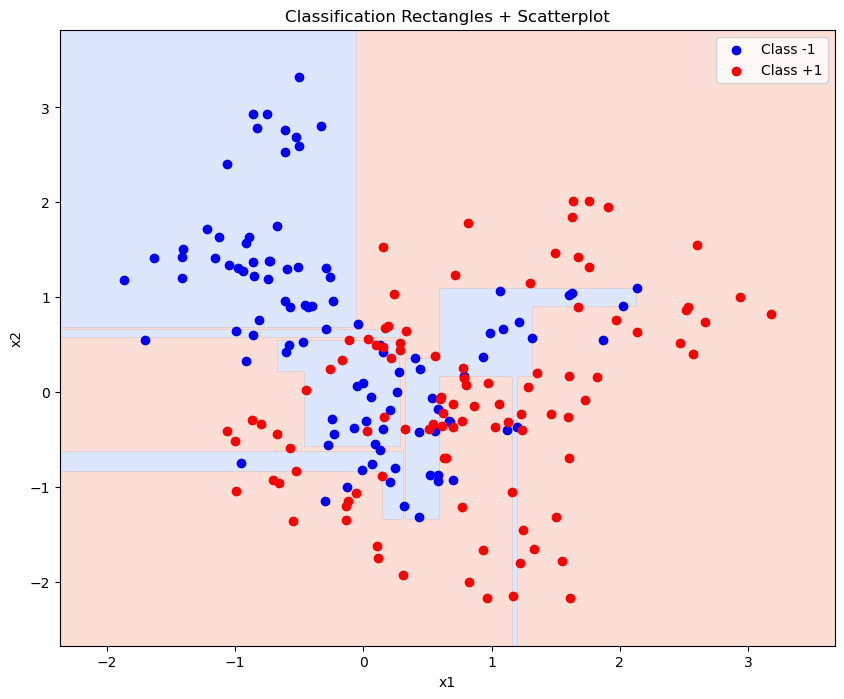

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Predict one point using your custom tree
# -------------------------------------------------
def predict_one(point, tree):
    if "label" in tree:
        return tree["label"]
    
    if point[tree["feature"]] <= tree["threshold"]:
        return predict_one(point, tree["left"])
    else:
        return predict_one(point, tree["right"])


# Predict all points
def predict(X, tree):
    return np.array([predict_one(p, tree) for p in X])


# -------------------------------------------------
# Training Error
# -------------------------------------------------
y_pred = predict(x, tree)

training_error = np.mean(y_pred != y)

print("Training Error =", training_error)


# -------------------------------------------------
# Plot classifying rectangles + scatterplot
# -------------------------------------------------
# Create mesh grid over feature space
x1_min, x1_max = x[:,0].min()-0.5, x[:,0].max()+0.5
x2_min, x2_max = x[:,1].min()-0.5, x[:,1].max()+0.5

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid_points = np.c_[xx1.ravel(), xx2.ravel()]

# Predict class for every grid point
Z = predict(grid_points, tree)
Z = Z.reshape(xx1.shape)

# -------------------------------------------------
# Plot background rectangles
# -------------------------------------------------
plt.figure(figsize=(10,8))

plt.contourf(xx1, xx2, Z, alpha=0.3, levels=[-1,0,1], cmap="coolwarm")

# Scatter original data
plt.scatter(x[y==-1][:,0], x[y==-1][:,1], color="blue", label="Class -1")
plt.scatter(x[y==1][:,0], x[y==1][:,1], color="red", label="Class +1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classification Rectangles + Scatterplot")
plt.legend()
plt.show()

In [7]:
from sklearn.tree import plot_tree

help(plot_tree)

Help on function plot_tree in module sklearn.tree._export:

plot_tree(
    decision_tree,
    *,
    max_depth=None,
    feature_names=None,
    class_names=None,
    label='all',
    filled=False,
    impurity=True,
    node_ids=False,
    proportion=False,
    rounded=False,
    precision=3,
    ax=None,
    fontsize=None
)
    Plot a decision tree.

    The sample counts that are shown are weighted with any sample_weights that
    might be present.

    The visualization is fit automatically to the size of the axis.
    Use the ``figsize`` or ``dpi`` arguments of ``plt.figure``  to control
    the size of the rendering.

    Read more in the :ref:`User Guide <tree>`.

    .. versionadded:: 0.21

    Parameters
    ----------
    decision_tree : decision tree regressor or classifier
        The decision tree to be plotted.

    max_depth : int, default=None
        The maximum depth of the representation. If None, the tree is fully
        generated.

    feature_names : array-like o